In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import datetime as dt 

DATABASE_FILE="../data/20260512102024__stream_retina__24h.db"

In [2]:
display(Markdown(f"""
# Retina Production Server FIE Stream Analysis

| Field                  | Value |
| ---------------------- | ----- |
| Author                 | Ufuk Bombar |
| Notebook Creation Date | 2026-05-07 |
| Notebook Running Time  | {dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")} |
| Database File          | `{DATABASE_FILE}` |

## Motivation

This notebook presents an initial exploratory analysis of the data generated by the Retina 
production deployment.

## Research Questions

1. **What does the forwarding score distribution look like?**
2. **How many FDHs does the current system actually discover?**
3. **What does the distribution of the mean FDH refresh cadence look like?**
4. **What are the observed hit rates per IP address? Are they really below 1 packet per second per IP?**
5. **How many PDs map to each FDH? What is the distribution of $k_H$?**
6. **How often does the forwarding decision actually change for an FDH observed multiple times?**

## Prerequisites

- To understand the concepts used in this notebook (FDH, PD, FIE, etc.), refer to the
  accompanying draft: *Moving Retina to Forwarding Decision Handle-Centered Probing* (Friedman, 2026).
- The forwarding score metric used in this notebook is introduced in the following paper:
  Bombar, U., Vermeulen, K., Fourmaux, O., and Friedman, T. *Forwarding Score: A New Metric
  for Assessing the Quality of Internet Route Surveys*. Poster at IMC '25: Proceedings of the
  2025 ACM Internet Measurement Conference. https://dl.acm.org/doi/10.1145/3730567.3768596
- To run this notebook, an SQLite database file containing the streamed FIE data must be
  present in the working directory.

## Methodology

The production instance of Retina runs on 10 GCP agents scattered across the globe. The
Retina orchestrator sends Probing Directives (PDs) to these agents and collects the resulting
Forwarding Information Elements (FIEs). Only *complete* FIEs — those where both near and far
addresses were successfully resolved — are streamed.

Streaming is performed via the endpoint `iprl.dioptra.io/api/v1/stream` using the `fetch_for.sh`
script, invoked with a duration argument (e.g. `./fetch_for.sh 1h`). The script runs for the
specified duration and saves all streamed FIEs into a local SQLite database under the table
`fies`. The database file is named according to the convention `YYYYMMDD__HHMMSS__D.db`,
where `D` is the duration.
"""))

# The file is loaded from the local directory.
con = sqlite3.connect(DATABASE_FILE)


# Retina Production Server FIE Stream Analysis

| Field                  | Value |
| ---------------------- | ----- |
| Author                 | Ufuk Bombar |
| Notebook Creation Date | 2026-05-07 |
| Notebook Running Time  | 2026-05-14 12:23:25 |
| Database File          | `../data/20260512102024__stream_retina__24h.db` |

## Motivation

This notebook presents an initial exploratory analysis of the data generated by the Retina 
production deployment.

## Research Questions

1. **What does the forwarding score distribution look like?**
2. **How many FDHs does the current system actually discover?**
3. **What does the distribution of the mean FDH refresh cadence look like?**
4. **What are the observed hit rates per IP address? Are they really below 1 packet per second per IP?**
5. **How many PDs map to each FDH? What is the distribution of $k_H$?**
6. **How often does the forwarding decision actually change for an FDH observed multiple times?**

## Prerequisites

- To understand the concepts used in this notebook (FDH, PD, FIE, etc.), refer to the
  accompanying draft: *Moving Retina to Forwarding Decision Handle-Centered Probing* (Friedman, 2026).
- The forwarding score metric used in this notebook is introduced in the following paper:
  Bombar, U., Vermeulen, K., Fourmaux, O., and Friedman, T. *Forwarding Score: A New Metric
  for Assessing the Quality of Internet Route Surveys*. Poster at IMC '25: Proceedings of the
  2025 ACM Internet Measurement Conference. https://dl.acm.org/doi/10.1145/3730567.3768596
- To run this notebook, an SQLite database file containing the streamed FIE data must be
  present in the working directory.

## Methodology

The production instance of Retina runs on 10 GCP agents scattered across the globe. The
Retina orchestrator sends Probing Directives (PDs) to these agents and collects the resulting
Forwarding Information Elements (FIEs). Only *complete* FIEs — those where both near and far
addresses were successfully resolved — are streamed.

Streaming is performed via the endpoint `iprl.dioptra.io/api/v1/stream` using the `fetch_for.sh`
script, invoked with a duration argument (e.g. `./fetch_for.sh 1h`). The script runs for the
specified duration and saves all streamed FIEs into a local SQLite database under the table
`fies`. The database file is named according to the convention `YYYYMMDD__HHMMSS__D.db`,
where `D` is the duration.


In [13]:
display(Markdown("""
## Dataset Metadata
Before diving into the analysis, we first characterize the dataset to ensure its integrity.
We report the total number of complete FIEs streamed, the time range covered, and whether
any sequence numbers are missing. Since the sequence number starts at 0 and increments by 1
for each FIE, any gap indicates that some FIEs were dropped during streaming or ingestion.
Note that the stream contains only *complete* FIEs — those where both the near and far
addresses were successfully resolved. Incomplete FIEs (where at least one address is nil)
are filtered out by the Retina orchestrator before streaming.
"""))

df_meta = pd.read_sql_query("""
    SELECT
        COUNT(*)                            as total_fies,
        MIN(production_timestamp)           as start_time,
        MAX(production_timestamp)           as stop_time,
        MIN(sequence_number)                as seq_min,
        MAX(sequence_number)                as seq_max,
        COUNT(DISTINCT sequence_number)     as seq_distinct,
        COUNT(DISTINCT CASE WHEN ip_version = 4 THEN destination_address END) as distinct_ipv4,
        COUNT(DISTINCT CASE WHEN ip_version = 6 THEN destination_address END) as distinct_ipv6
    FROM fies
""", con)

total         = df_meta['total_fies'].iloc[0]
start_time    = pd.Timestamp(df_meta['start_time'].iloc[0])
stop_time     = pd.Timestamp(df_meta['stop_time'].iloc[0])
seq_min       = df_meta['seq_min'].iloc[0]
seq_max       = df_meta['seq_max'].iloc[0]
seq_distinct  = df_meta['seq_distinct'].iloc[0]
distinct_ipv4 = df_meta['distinct_ipv4'].iloc[0]
distinct_ipv6 = df_meta['distinct_ipv6'].iloc[0]

duration = stop_time - start_time
expected = seq_max - seq_min + 1
missing  = expected - seq_distinct

seconds = int(duration.total_seconds())
hours   = seconds // 3600
minutes = (seconds % 3600) // 60
seconds = seconds % 60

missing_perc = 100 * missing / expected 

display(Markdown(f"""
| Metric | Value |
|--------|-------|
| Start time | `{start_time.strftime("%Y-%m-%d %H:%M:%S")}` |
| Stop time | `{stop_time.strftime("%Y-%m-%d %H:%M:%S")}` |
| Duration | `{hours} hours {minutes} minutes {seconds} seconds` |
| Total FIEs streamed | `{total}` |
| FIE streaming rate per second | `{int(100 * total / duration.total_seconds()) / 100}` |
| Missing FIEs | `{missing} %{missing_perc:.2f}` {"✓ none missing" if missing == 0 else "⚠ gaps detected"} |
| Distinct IPv4 destinations | `{distinct_ipv4}` |
| Distinct IPv6 destinations | `{distinct_ipv6}` |
"""))


## Dataset Metadata
Before diving into the analysis, we first characterize the dataset to ensure its integrity.
We report the total number of complete FIEs streamed, the time range covered, and whether
any sequence numbers are missing. Since the sequence number starts at 0 and increments by 1
for each FIE, any gap indicates that some FIEs were dropped during streaming or ingestion.
Note that the stream contains only *complete* FIEs — those where both the near and far
addresses were successfully resolved. Incomplete FIEs (where at least one address is nil)
are filtered out by the Retina orchestrator before streaming.



| Metric | Value |
|--------|-------|
| Start time | `2026-05-12 10:40:24` |
| Stop time | `2026-05-13 10:40:24` |
| Duration | `23 hours 59 minutes 59 seconds` |
| Total FIEs streamed | `13162636` |
| FIE streaming rate per second | `152.34` |
| Missing FIEs | `184111 %1.38` ⚠ gaps detected |
| Distinct IPv4 destinations | `233230` |
| Distinct IPv6 destinations | `4882` |



## Question 1: Forwarding Score Distribution
The forwarding score $F(a)$ of an address $a$ is defined as the number of distinct
destination /24 prefixes for which $a$ appears as the near address, as introduced in
[Bombar et al., IMC '25]. This metric provides a measure of how broadly each router
is observed forwarding traffic across the destination address space.
Since the forwarding score is defined over /24 prefixes, IPv6 addresses are excluded
from this analysis.



| Metric | Value |
|--------|-------|
| Total addresses with non-zero forwarding score | `130376` |
| Max forwarding score | `230` |
| Median forwarding score | `1` |
| Mean forwarding score | `2.11` |


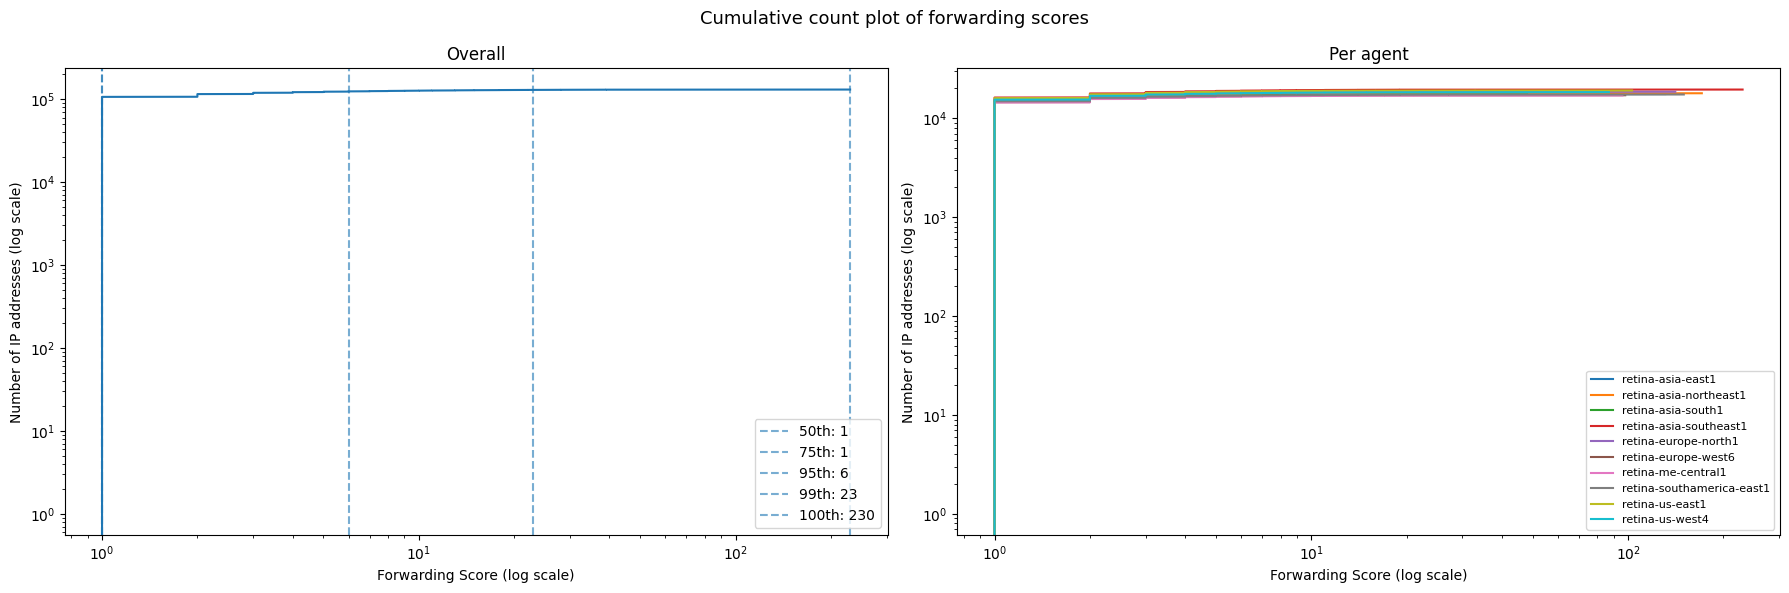

In [4]:
display(Markdown("""
## Question 1: Forwarding Score Distribution
The forwarding score $F(a)$ of an address $a$ is defined as the number of distinct
destination /24 prefixes for which $a$ appears as the near address, as introduced in
[Bombar et al., IMC '25]. This metric provides a measure of how broadly each router
is observed forwarding traffic across the destination address space.
Since the forwarding score is defined over /24 prefixes, IPv6 addresses are excluded
from this analysis.
"""))

df_raw = pd.read_sql_query("""
    SELECT agent_id, near_reply_address, destination_address
    FROM fies
    WHERE ip_version = 4
""", con)

df_raw = df_raw[~df_raw['near_reply_address'].str.contains(':')]
df_raw['prefix24'] = df_raw['destination_address'].apply(
    lambda ip: '.'.join(ip.split('.')[:3]) + '.0'
)

df_fs = (
    df_raw
    .groupby('near_reply_address')['prefix24']
    .nunique()
    .reset_index()
    .rename(columns={'prefix24': 'forwarding_score'})
    .sort_values('forwarding_score', ascending=False)
)

display(Markdown(f"""
| Metric | Value |
|--------|-------|
| Total addresses with non-zero forwarding score | `{len(df_fs)}` |
| Max forwarding score | `{df_fs['forwarding_score'].max()}` |
| Median forwarding score | `{df_fs['forwarding_score'].median():.0f}` |
| Mean forwarding score | `{df_fs['forwarding_score'].mean():.2f}` |
"""))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: overall ---
ax = axes[0]
sorted_fs = df_fs['forwarding_score'].sort_values()
ax.plot(sorted_fs.values, range(len(sorted_fs)))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Forwarding Score (log scale)')
ax.set_ylabel('Number of IP addresses (log scale)')
ax.set_title('Overall')
for p, label in zip([50, 75, 95, 99, 100], ['50th', '75th', '95th', '99th', '100th']):
    val = sorted_fs.quantile(p / 100)
    ax.axvline(val, linestyle='--', alpha=0.6, label=f'{label}: {val:.0f}')
ax.legend()

# --- Plot 2: per agent ---
ax = axes[1]
agents = sorted(df_raw['agent_id'].unique())
cmap = plt.get_cmap('tab10')
for i, agent in enumerate(agents):
    df_agent = (
        df_raw[df_raw['agent_id'] == agent]
        .groupby('near_reply_address')['prefix24']
        .nunique()
        .sort_values()
    )
    ax.plot(df_agent.values, range(len(df_agent)),
            color=cmap(i), label=agent)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Forwarding Score (log scale)')
ax.set_ylabel('Number of IP addresses (log scale)')
ax.set_title('Per agent')
ax.legend(fontsize=8)

fig.suptitle('Cumulative count plot of forwarding scores', fontsize=13)
plt.tight_layout()
plt.show()


## Question 2: FDH Discovery
A Forwarding Decision Handle (FDH) is defined as a distinct `(near_reply_address, destination_address)` pair,
representing a unique forwarding decision observed in the data. Here we report how many
distinct FDHs the current production deployment of Retina discovers over the observation
period, and characterize the distribution of how many times each FDH is observed.



| Metric | Value |
|--------|-------|
| Total FDHs discovered | `281024` |
| Max observations per FDH | `193` |
| Median observations per FDH | `6` |
| Mean observations per FDH | `46.84` |
| FDHs observed only once | `76666` |


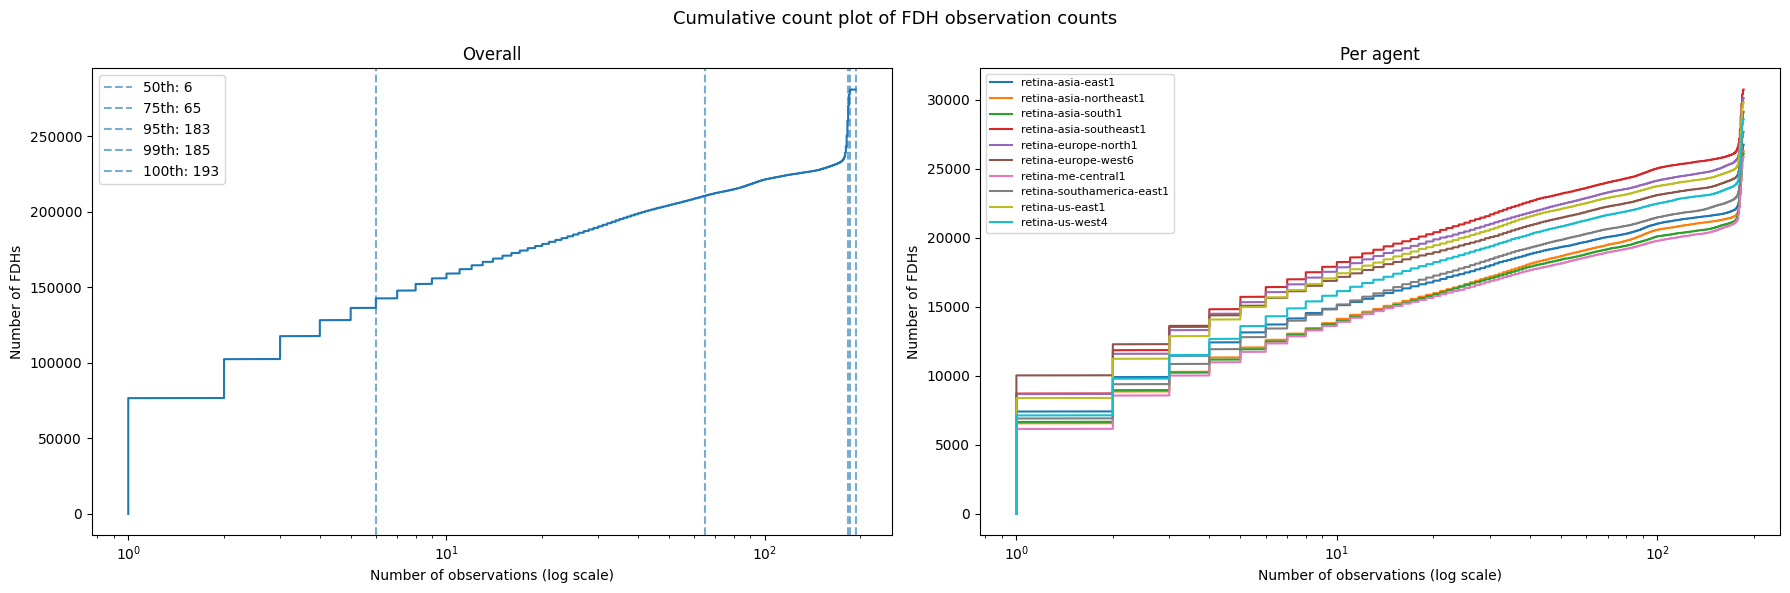

In [5]:
display(Markdown("""
## Question 2: FDH Discovery
A Forwarding Decision Handle (FDH) is defined as a distinct `(near_reply_address, destination_address)` pair,
representing a unique forwarding decision observed in the data. Here we report how many
distinct FDHs the current production deployment of Retina discovers over the observation
period, and characterize the distribution of how many times each FDH is observed.
"""))

df_fdh = pd.read_sql_query("""
    SELECT agent_id, near_reply_address, destination_address, COUNT(*) as observations
    FROM fies
    GROUP BY agent_id, near_reply_address, destination_address
    ORDER BY observations DESC
""", con)

df_fdh_overall = (
    df_fdh
    .groupby(['near_reply_address', 'destination_address'])['observations']
    .sum()
    .reset_index()
)

display(Markdown(f"""
| Metric | Value |
|--------|-------|
| Total FDHs discovered | `{len(df_fdh_overall)}` |
| Max observations per FDH | `{df_fdh_overall['observations'].max()}` |
| Median observations per FDH | `{df_fdh_overall['observations'].median():.0f}` |
| Mean observations per FDH | `{df_fdh_overall['observations'].mean():.2f}` |
| FDHs observed only once | `{(df_fdh_overall['observations'] == 1).sum()}` |
"""))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: overall ---
ax = axes[0]
sorted_obs = df_fdh_overall['observations'].sort_values()
ax.plot(sorted_obs.values, range(len(sorted_obs)))
ax.set_xscale('log')
ax.set_xlabel('Number of observations (log scale)')
ax.set_ylabel('Number of FDHs')
ax.set_title('Overall')
for p, label in zip([50, 75, 95, 99, 100], ['50th', '75th', '95th', '99th', '100th']):
    val = sorted_obs.quantile(p / 100)
    ax.axvline(val, linestyle='--', alpha=0.6, label=f'{label}: {val:.0f}')
ax.legend()

# --- Plot 2: per agent ---
ax = axes[1]
agents = sorted(df_fdh['agent_id'].unique())
cmap = plt.get_cmap('tab10')
for i, agent in enumerate(agents):
    df_agent = (
        df_fdh[df_fdh['agent_id'] == agent]['observations']
        .sort_values()
    )
    ax.plot(df_agent.values, range(len(df_agent)),
            color=cmap(i), label=agent)
ax.set_xscale('log')
ax.set_xlabel('Number of observations (log scale)')
ax.set_ylabel('Number of FDHs')
ax.set_title('Per agent')
ax.legend(fontsize=8)

fig.suptitle('Cumulative count plot of FDH observation counts', fontsize=13)
plt.tight_layout()
plt.show()


## Question 3: FDH Mean Refresh Cadence
For each FDH $(a_n, d)$ observed more than once, we compute the mean time between
consecutive observations (sorted by `production_timestamp`). The target refresh cadence set by the
Retina proposal is $\tau_{FDH} = 20s$ — fast enough to track sub-one-minute changes
in internet routing. FDHs observed only once have no inter-observation gap and are
excluded from this analysis.



| Metric | Value |
|--------|-------|
| FDHs with cadence estimate (observed > 1x) | `204358` |
| FDHs observed only once (excluded) | `76666` |
| Target cadence $\tau_{FDH}$ | `20 s` |
| Mean of mean cadences | `7275.74 s` |
| Median of mean cadences | `2433.07 s` |
| % FDHs at or below target (≤ 20s) | `0.0%` |


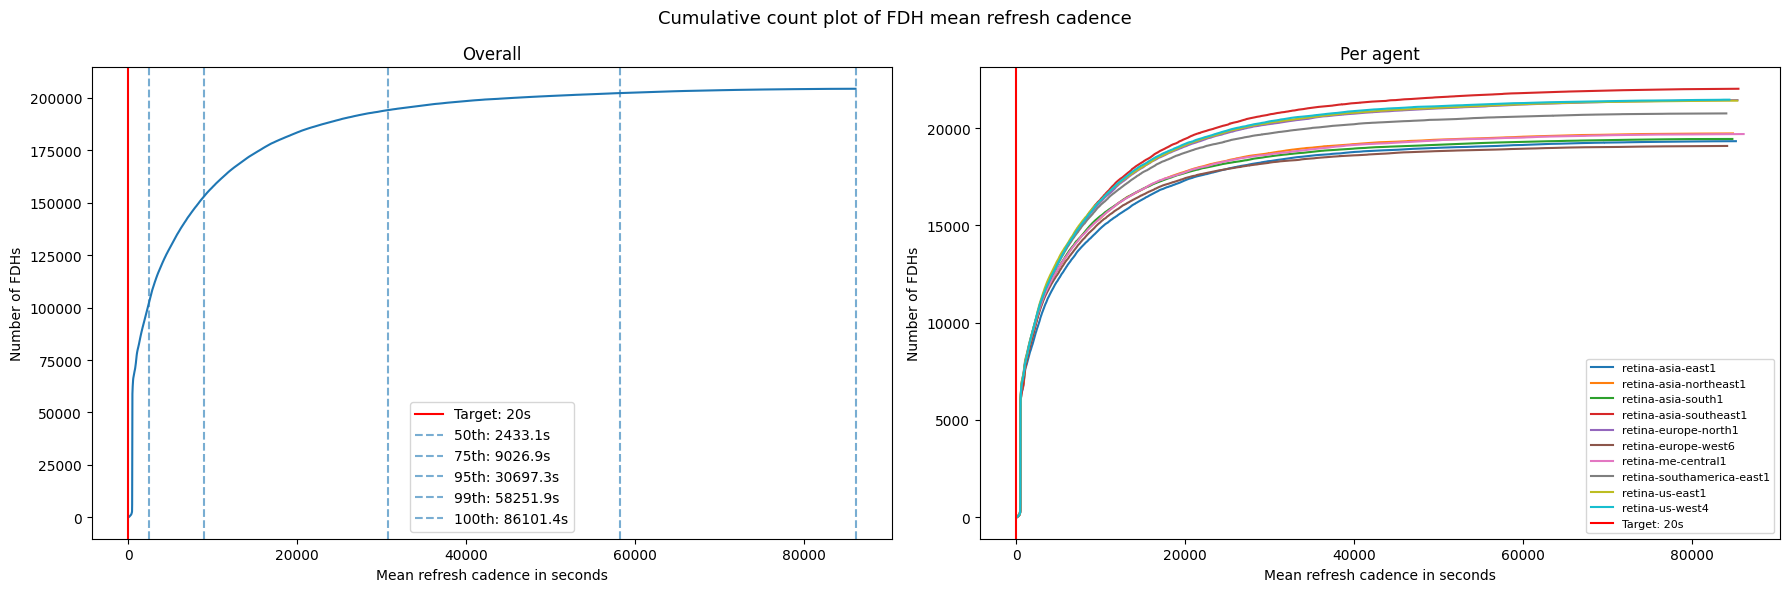

In [6]:
display(Markdown("""
## Question 3: FDH Mean Refresh Cadence
For each FDH $(a_n, d)$ observed more than once, we compute the mean time between
consecutive observations (sorted by `production_timestamp`). The target refresh cadence set by the
Retina proposal is $\\tau_{FDH} = 20s$ — fast enough to track sub-one-minute changes
in internet routing. FDHs observed only once have no inter-observation gap and are
excluded from this analysis.
"""))

df_times = pd.read_sql_query("""
    SELECT agent_id, near_reply_address, destination_address, production_timestamp
    FROM fies
    ORDER BY near_reply_address, destination_address, production_timestamp
""", con)

df_times['production_timestamp'] = pd.to_datetime(df_times['production_timestamp'])

df_cadence = (
    df_times
    .groupby(['near_reply_address', 'destination_address'])['production_timestamp']
    .apply(lambda t: t.diff().dt.total_seconds().dropna().mean())
    .dropna()
    .reset_index()
    .rename(columns={'production_timestamp': 'mean_cadence_s'})
)

df_cadence_agent = (
    df_times
    .groupby(['agent_id', 'near_reply_address', 'destination_address'])['production_timestamp']
    .apply(lambda t: t.diff().dt.total_seconds().dropna().mean())
    .dropna()
    .reset_index()
    .rename(columns={'production_timestamp': 'mean_cadence_s'})
)

display(Markdown(f"""
| Metric | Value |
|--------|-------|
| FDHs with cadence estimate (observed > 1x) | `{len(df_cadence)}` |
| FDHs observed only once (excluded) | `{len(df_fdh_overall) - len(df_cadence)}` |
| Target cadence $\\tau_{{FDH}}$ | `20 s` |
| Mean of mean cadences | `{df_cadence['mean_cadence_s'].mean():.2f} s` |
| Median of mean cadences | `{df_cadence['mean_cadence_s'].median():.2f} s` |
| % FDHs at or below target (≤ 20s) | `{100 * (df_cadence['mean_cadence_s'] <= 20).mean():.1f}%` |
"""))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: overall ---
ax = axes[0]
sorted_cadence = df_cadence['mean_cadence_s'].sort_values()
ax.plot(sorted_cadence.values, range(len(sorted_cadence)))
ax.axvline(20, color='red', linestyle='-', linewidth=1.5, label='Target: 20s')
ax.set_xlabel('Mean refresh cadence in seconds')
ax.set_ylabel('Number of FDHs')
ax.set_title('Overall')
for p, label in zip([50, 75, 95, 99, 100], ['50th', '75th', '95th', '99th', '100th']):
    val = sorted_cadence.quantile(p / 100)
    ax.axvline(val, linestyle='--', alpha=0.6, label=f'{label}: {val:.1f}s')
ax.legend()

# --- Plot 2: per agent ---
ax = axes[1]
agents = sorted(df_cadence_agent['agent_id'].unique())
cmap = plt.get_cmap('tab10')
for i, agent in enumerate(agents):
    df_agent = (
        df_cadence_agent[df_cadence_agent['agent_id'] == agent]['mean_cadence_s']
        .sort_values()
    )
    ax.plot(df_agent.values, range(len(df_agent)),
            color=cmap(i), label=agent)
ax.axvline(20, color='red', linestyle='-', linewidth=1.5, label='Target: 20s')
ax.set_xlabel('Mean refresh cadence in seconds')
ax.set_ylabel('Number of FDHs')
ax.set_title('Per agent')
ax.legend(fontsize=8)

fig.suptitle('Cumulative count plot of FDH mean refresh cadence', fontsize=13)
plt.tight_layout()
plt.show()


## Question 4: Hit Rates per Response Address
For each IP address that appears as either a near or far reply, we compute the
hit rate as the total number of responses divided by the dataset duration.
The responsible-probing constraint requires $\rho_i \leq \rho_{max} = 1$ pkt/s
for every IP $i$, decoupled from the cycle length as proposed in the Friedman (2026) draft.



| Metric | Value |
|--------|-------|
| Distinct response IPs | `170861` |
| Dataset duration | `86399.5 s` |
| Max hit rate | `0.0265 pkt/s` |
| Median hit rate | `0.0012 pkt/s` |
| Mean hit rate | `0.0018 pkt/s` |
| IPs above 1 pkt/s | `0` ✓ none |


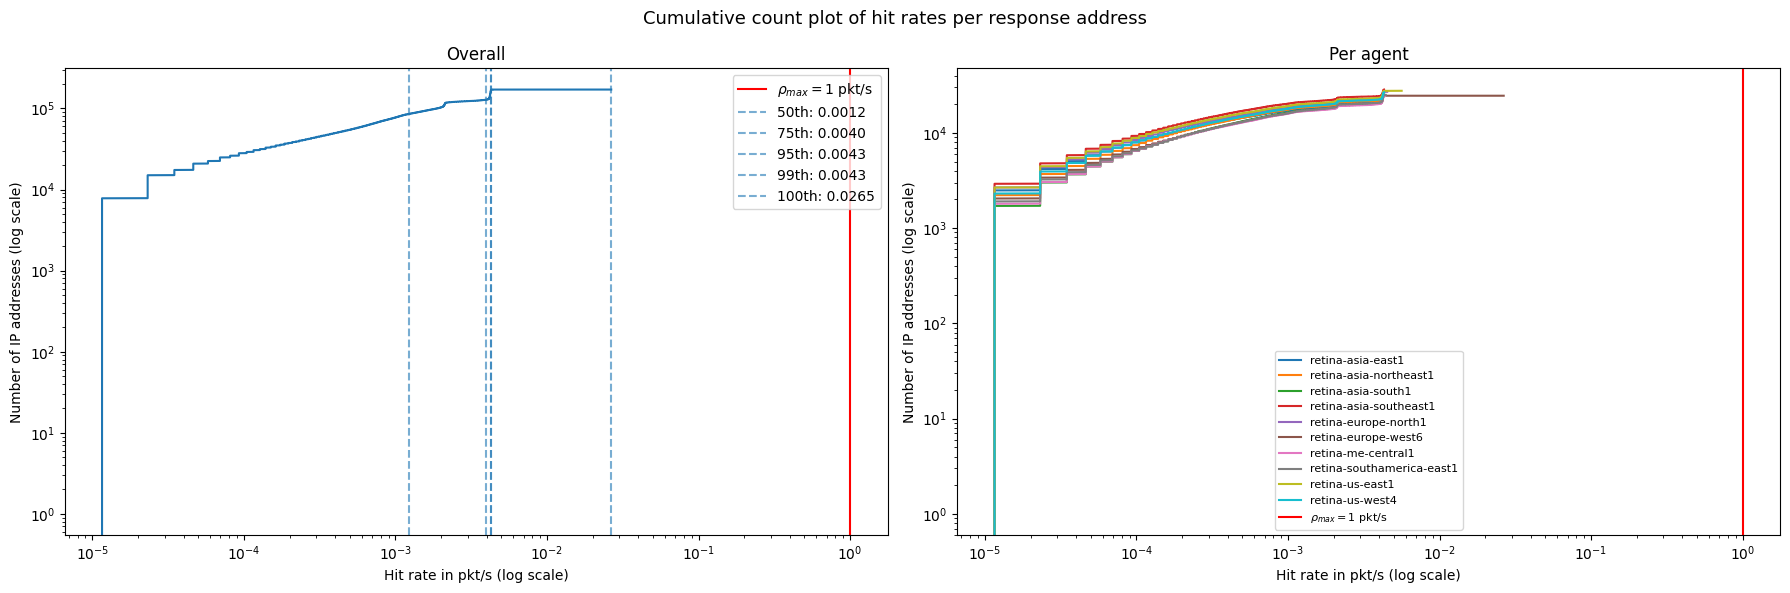

In [7]:
display(Markdown("""
## Question 4: Hit Rates per Response Address
For each IP address that appears as either a near or far reply, we compute the
hit rate as the total number of responses divided by the dataset duration.
The responsible-probing constraint requires $\\rho_i \\leq \\rho_{max} = 1$ pkt/s
for every IP $i$, decoupled from the cycle length as proposed in the Friedman (2026) draft.
"""))

df_duration = pd.read_sql_query("""
    SELECT
        (JULIANDAY(MAX(production_timestamp)) - JULIANDAY(MIN(production_timestamp))) * 86400.0 AS duration_s
    FROM fies
""", con)
duration_s = df_duration['duration_s'].iloc[0]

df_hits = pd.read_sql_query("""
    SELECT addr, COUNT(*) as hits
    FROM (
        SELECT near_reply_address AS addr FROM fies
        UNION ALL
        SELECT far_reply_address  AS addr FROM fies
    )
    WHERE addr IS NOT NULL AND addr != ''
    GROUP BY addr
""", con)
df_hits['hit_rate'] = df_hits['hits'] / duration_s

df_hits_agent = pd.read_sql_query("""
    SELECT agent_id, addr, COUNT(*) as hits
    FROM (
        SELECT agent_id, near_reply_address AS addr FROM fies
        UNION ALL
        SELECT agent_id, far_reply_address  AS addr FROM fies
    )
    WHERE addr IS NOT NULL AND addr != ''
    GROUP BY agent_id, addr
""", con)
df_hits_agent['hit_rate'] = df_hits_agent['hits'] / duration_s

n_above = (df_hits['hit_rate'] > 1).sum()
display(Markdown(f"""
| Metric | Value |
|--------|-------|
| Distinct response IPs | `{len(df_hits)}` |
| Dataset duration | `{duration_s:.1f} s` |
| Max hit rate | `{df_hits['hit_rate'].max():.4f} pkt/s` |
| Median hit rate | `{df_hits['hit_rate'].median():.4f} pkt/s` |
| Mean hit rate | `{df_hits['hit_rate'].mean():.4f} pkt/s` |
| IPs above 1 pkt/s | `{n_above}` {"✓ none" if n_above == 0 else "⚠ constraint violated"} |
"""))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: overall ---
ax = axes[0]
sorted_rates = df_hits['hit_rate'].sort_values()
ax.plot(sorted_rates.values, range(len(sorted_rates)))
ax.set_xscale('log')
ax.set_yscale('log')
ax.axvline(1, color='red', linestyle='-', linewidth=1.5, label='$\\rho_{max} = 1$ pkt/s')
ax.set_xlabel('Hit rate in pkt/s (log scale)')
ax.set_ylabel('Number of IP addresses (log scale)')
ax.set_title('Overall')
for p, label in zip([50, 75, 95, 99, 100], ['50th', '75th', '95th', '99th', '100th']):
    val = sorted_rates.quantile(p / 100)
    ax.axvline(val, linestyle='--', alpha=0.6, label=f'{label}: {val:.4f}')
ax.legend()

# --- Plot 2: per agent ---
ax = axes[1]
agents = sorted(df_hits_agent['agent_id'].unique())
cmap = plt.get_cmap('tab10')
for i, agent in enumerate(agents):
    df_agent = (
        df_hits_agent[df_hits_agent['agent_id'] == agent]['hit_rate']
        .sort_values()
    )
    ax.plot(df_agent.values, range(len(df_agent)),
            color=cmap(i), label=agent)
ax.set_xscale('log')
ax.set_yscale('log')
ax.axvline(1, color='red', linestyle='-', linewidth=1.5, label='$\\rho_{max} = 1$ pkt/s')
ax.set_xlabel('Hit rate in pkt/s (log scale)')
ax.set_ylabel('Number of IP addresses (log scale)')
ax.set_title('Per agent')
ax.legend(fontsize=8)

fig.suptitle('Cumulative count plot of hit rates per response address', fontsize=13)
plt.tight_layout()
plt.show()


## Question 5: PD-to-FDH Mapping
A Probing Directive (PD) is reconstructed from the FIEs as a distinct `(agent_id, destination_address, near_probe_ttl)`
triple. An FDH $(a_n, d)$ may be targeted by multiple PDs — for example from different agents or
with different near TTLs. The number of PDs mapped to an FDH is denoted $k_H$ in the Friedman (2026)
draft. A higher $k_H$ means the FDH is covered by more PDs, and each PD is invoked less frequently
at interval $k_H \times \tau_{FDH}$, spreading the probing load across vantage points.



| Metric | Value |
|--------|-------|
| Total FDHs | `281024` |
| Max $k_H$ | `2` |
| Median $k_H$ | `1` |
| Mean $k_H$ | `1.00` |
| FDHs with $k_H = 1$ (single PD) | `281002` |
| FDHs with $k_H > 1$ (multiple PDs) | `22` |


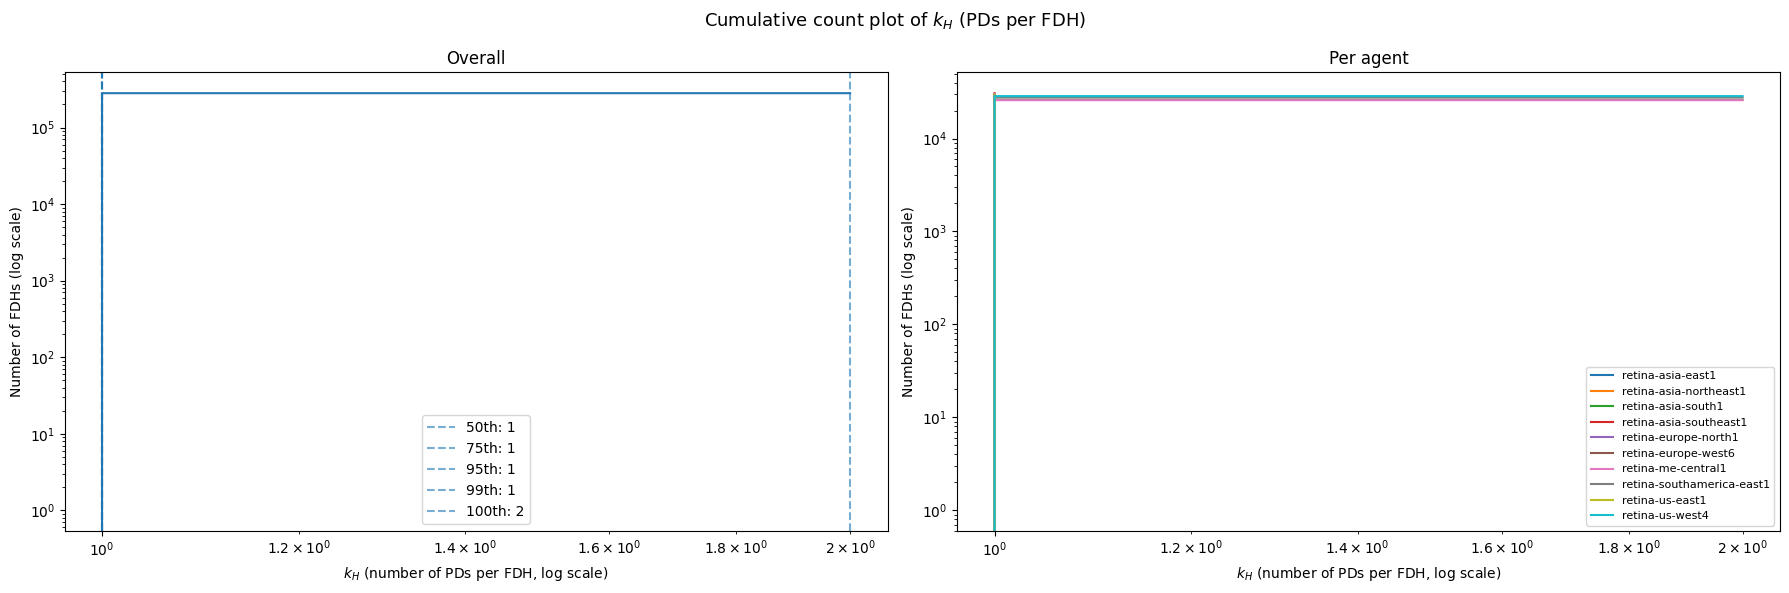

In [8]:
display(Markdown("""
## Question 5: PD-to-FDH Mapping
A Probing Directive (PD) is reconstructed from the FIEs as a distinct `(agent_id, destination_address, near_probe_ttl)`
triple. An FDH $(a_n, d)$ may be targeted by multiple PDs — for example from different agents or
with different near TTLs. The number of PDs mapped to an FDH is denoted $k_H$ in the Friedman (2026)
draft. A higher $k_H$ means the FDH is covered by more PDs, and each PD is invoked less frequently
at interval $k_H \\times \\tau_{FDH}$, spreading the probing load across vantage points.
"""))

df_pd_fdh = pd.read_sql_query("""
    SELECT
        near_reply_address,
        destination_address,
        COUNT(DISTINCT agent_id || '|' || destination_address || '|' || near_probe_ttl) as k_H
    FROM fies
    WHERE near_reply_address IS NOT NULL AND near_reply_address != ''
    GROUP BY near_reply_address, destination_address
    ORDER BY k_H DESC
""", con)

n_above = (df_pd_fdh['k_H'] > 1).sum()
display(Markdown(f"""
| Metric | Value |
|--------|-------|
| Total FDHs | `{len(df_pd_fdh)}` |
| Max $k_H$ | `{df_pd_fdh['k_H'].max()}` |
| Median $k_H$ | `{df_pd_fdh['k_H'].median():.0f}` |
| Mean $k_H$ | `{df_pd_fdh['k_H'].mean():.2f}` |
| FDHs with $k_H = 1$ (single PD) | `{(df_pd_fdh['k_H'] == 1).sum()}` |
| FDHs with $k_H > 1$ (multiple PDs) | `{n_above}` |
"""))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: overall ---
ax = axes[0]
sorted_kH = df_pd_fdh['k_H'].sort_values()
ax.plot(sorted_kH.values, range(len(sorted_kH)))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$k_H$ (number of PDs per FDH, log scale)')
ax.set_ylabel('Number of FDHs (log scale)')
ax.set_title('Overall')
for p, label in zip([50, 75, 95, 99, 100], ['50th', '75th', '95th', '99th', '100th']):
    val = sorted_kH.quantile(p / 100)
    ax.axvline(val, linestyle='--', alpha=0.6, label=f'{label}: {val:.0f}')
ax.legend()

# --- Plot 2: per agent ---
df_pd_fdh_agent = pd.read_sql_query("""
    SELECT
        agent_id,
        near_reply_address,
        destination_address,
        COUNT(DISTINCT agent_id || '|' || destination_address || '|' || near_probe_ttl) as k_H
    FROM fies
    WHERE near_reply_address IS NOT NULL AND near_reply_address != ''
    GROUP BY agent_id, near_reply_address, destination_address
    ORDER BY k_H DESC
""", con)

ax = axes[1]
agents = sorted(df_pd_fdh_agent['agent_id'].unique())
cmap = plt.get_cmap('tab10')
for i, agent in enumerate(agents):
    sorted_agent_kH = (
        df_pd_fdh_agent[df_pd_fdh_agent['agent_id'] == agent]['k_H']
        .sort_values()
    )
    ax.plot(sorted_agent_kH.values, range(len(sorted_agent_kH)),
            color=cmap(i), label=agent)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$k_H$ (number of PDs per FDH, log scale)')
ax.set_ylabel('Number of FDHs (log scale)')
ax.set_title('Per agent')
ax.legend(fontsize=8)

fig.suptitle('Cumulative count plot of $k_H$ (PDs per FDH)', fontsize=13)
plt.tight_layout()
plt.show()


## Question 6: Forwarding Decision Changes
Retina's core purpose is to detect when forwarding decisions change over time. For each
FDH $(a_n, d)$ observed more than once, we check whether the far address $a_f$ changes
between consecutive observations (sorted by `production_timestamp`). A change is defined as two
consecutive observations of the same FDH yielding different `far_reply_address` values.
The change rate of an FDH with observations $a_f^{(1)}, a_f^{(2)}, \ldots, a_f^{(n)}$ is defined as:
$$\text{change rate} = \frac{\sum_{i=2}^{n} \mathbf{1}\left[a_f^{(i)} \neq a_f^{(i-1)}\right]}{n - 1}$$
where $n$ is the number of observations and the numerator counts the number of consecutive
pairs where the far address changed. A change rate of 1 means the far address changed at
every observation; a rate of 0 means it never changed.



| Metric | Value |
|--------|-------|
| FDHs observed more than once | `204358` |
| FDHs with at least one change | `8602` (`4.21%`) |
| FDHs that never changed | `195756` (`95.79%`) |
| Mean change rate per FDH | `0.0214` |
| Median change rate per FDH | `0.0000` |


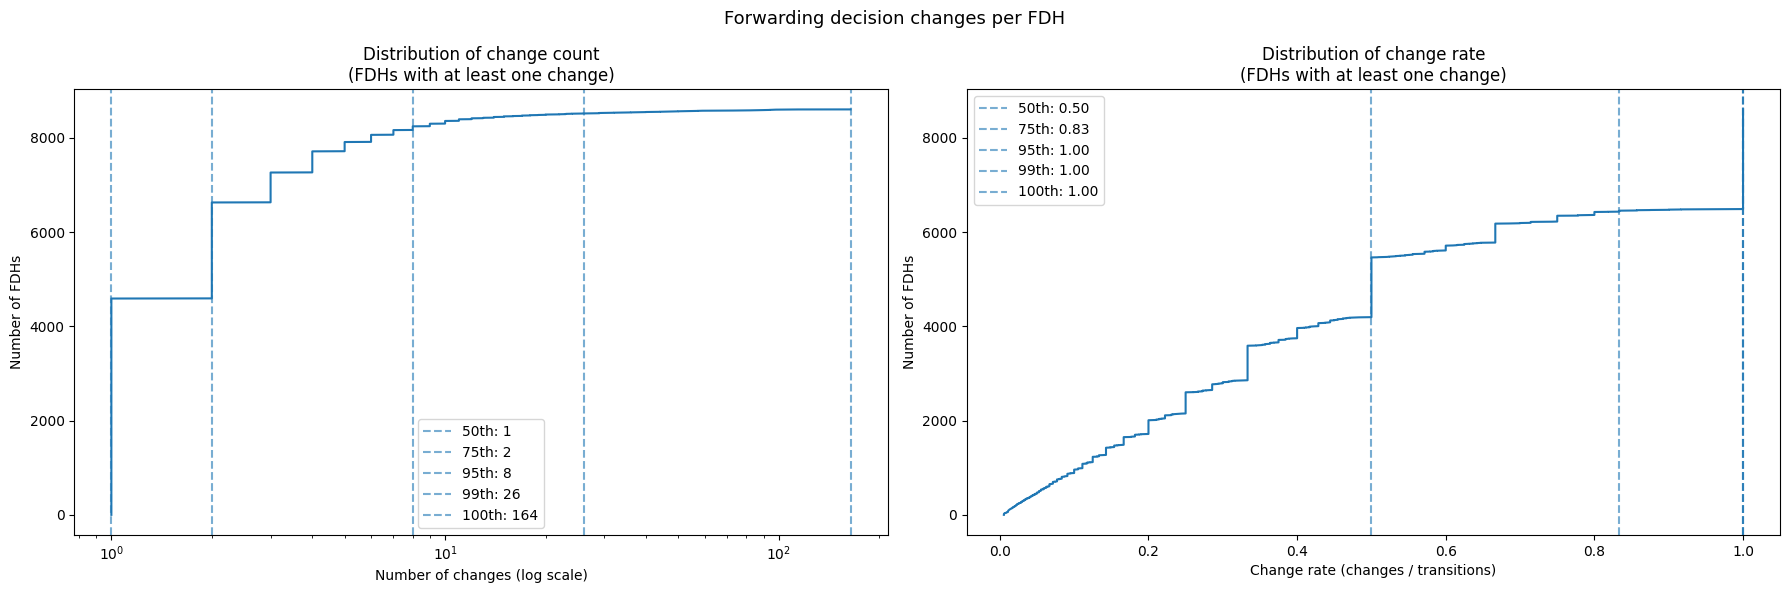

In [9]:
display(Markdown("""
## Question 6: Forwarding Decision Changes
Retina's core purpose is to detect when forwarding decisions change over time. For each
FDH $(a_n, d)$ observed more than once, we check whether the far address $a_f$ changes
between consecutive observations (sorted by `production_timestamp`). A change is defined as two
consecutive observations of the same FDH yielding different `far_reply_address` values.
The change rate of an FDH with observations $a_f^{(1)}, a_f^{(2)}, \\ldots, a_f^{(n)}$ is defined as:
$$\\text{change rate} = \\frac{\\sum_{i=2}^{n} \\mathbf{1}\\left[a_f^{(i)} \\neq a_f^{(i-1)}\\right]}{n - 1}$$
where $n$ is the number of observations and the numerator counts the number of consecutive
pairs where the far address changed. A change rate of 1 means the far address changed at
every observation; a rate of 0 means it never changed.
"""))

df_changes = pd.read_sql_query("""
    SELECT near_reply_address, destination_address, far_reply_address, production_timestamp
    FROM fies
    WHERE near_reply_address IS NOT NULL AND near_reply_address != ''
      AND far_reply_address  IS NOT NULL AND far_reply_address  != ''
    ORDER BY near_reply_address, destination_address, production_timestamp
""", con)

df_changes['production_timestamp'] = pd.to_datetime(df_changes['production_timestamp'])

def compute_changes(g):
    g = g.sort_values('production_timestamp')
    shifts = g['far_reply_address'] != g['far_reply_address'].shift(1)
    shifts.iloc[0] = False  # first row has no predecessor
    return pd.Series({
        'observations': len(g),
        'changes':      shifts.sum(),
    })

df_fdh_changes = (
    df_changes
    .groupby(['near_reply_address', 'destination_address'])
    .apply(compute_changes, include_groups=False)
    .reset_index()
)

# keep only FDHs observed more than once
df_fdh_changes = df_fdh_changes[df_fdh_changes['observations'] > 1].copy()
df_fdh_changes['change_rate'] = df_fdh_changes['changes'] / (df_fdh_changes['observations'] - 1)

n_any_change    = (df_fdh_changes['changes'] > 0).sum()
n_never_changed = (df_fdh_changes['changes'] == 0).sum()

display(Markdown(f"""
| Metric | Value |
|--------|-------|
| FDHs observed more than once | `{len(df_fdh_changes)}` |
| FDHs with at least one change | `{n_any_change}` (`{100 * n_any_change / len(df_fdh_changes):.2f}%`) |
| FDHs that never changed | `{n_never_changed}` (`{100 * n_never_changed / len(df_fdh_changes):.2f}%`) |
| Mean change rate per FDH | `{df_fdh_changes['change_rate'].mean():.4f}` |
| Median change rate per FDH | `{df_fdh_changes['change_rate'].median():.4f}` |
"""))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: distribution of number of changes per FDH ---
ax = axes[0]
changed = df_fdh_changes[df_fdh_changes['changes'] > 0]
sorted_changes = changed['changes'].sort_values()
ax.plot(sorted_changes.values, range(len(sorted_changes)))
ax.set_xscale('log')
ax.set_xlabel('Number of changes (log scale)')
ax.set_ylabel('Number of FDHs')
ax.set_title('Distribution of change count\n(FDHs with at least one change)')
for p, label in zip([50, 75, 95, 99, 100], ['50th', '75th', '95th', '99th', '100th']):
    val = sorted_changes.quantile(p / 100)
    ax.axvline(val, linestyle='--', alpha=0.6, label=f'{label}: {val:.0f}')
ax.legend()

# --- Plot 2: distribution of change rate per FDH ---
ax = axes[1]
sorted_rate = changed['change_rate'].sort_values()
ax.plot(sorted_rate.values, range(len(sorted_rate)))
ax.set_xlabel('Change rate (changes / transitions)')
ax.set_ylabel('Number of FDHs')
ax.set_title('Distribution of change rate\n(FDHs with at least one change)')
for p, label in zip([50, 75, 95, 99, 100], ['50th', '75th', '95th', '99th', '100th']):
    val = sorted_rate.quantile(p / 100)
    ax.axvline(val, linestyle='--', alpha=0.6, label=f'{label}: {val:.2f}')
ax.legend()

fig.suptitle('Forwarding decision changes per FDH', fontsize=13)
plt.tight_layout()
plt.show()


## Question 6.1: Distinct Far Addresses per Changing FDH
As a complement to the change rate analysis, we examine how many distinct far addresses
$a_f$ each changing FDH has been observed routing to. While the change rate captures
*how often* a forwarding decision changes, the number of distinct far addresses captures
*how many different next hops* it has been observed using. An FDH with a high number of
distinct far addresses may indicate load balancing, route flapping, or unstable routing.
FDHs that never changed (i.e. with only one distinct far address) are excluded.



| Metric | Value |
|--------|-------|
| FDHs with at least 2 distinct far addresses | `8602` |
| Max distinct far addresses | `18` |
| Median distinct far addresses | `2` |
| Mean distinct far addresses | `2.21` |
| FDHs with exactly 2 distinct far addresses | `7385` |


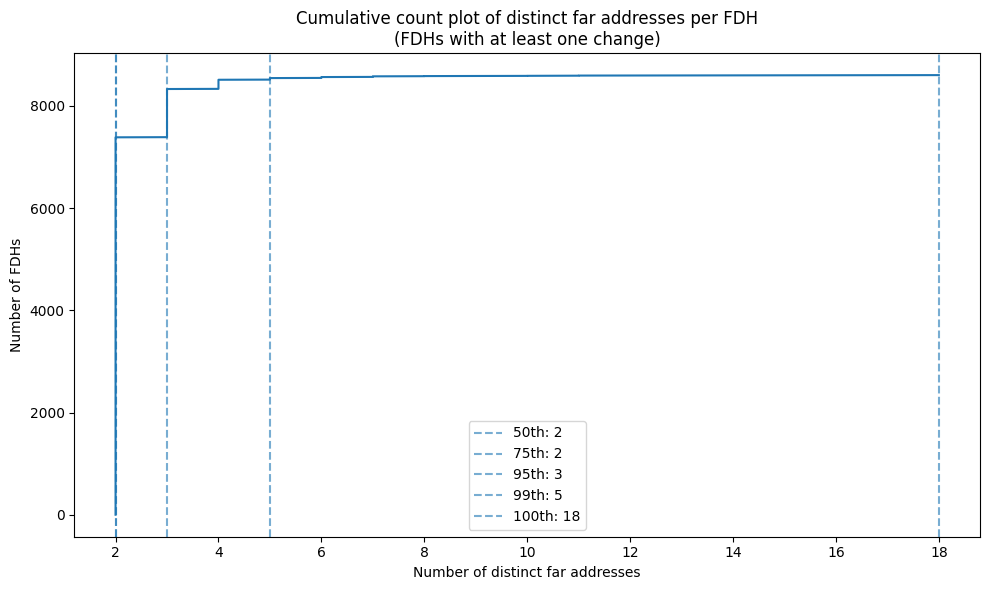

In [10]:
display(Markdown("""
## Question 6.1: Distinct Far Addresses per Changing FDH
As a complement to the change rate analysis, we examine how many distinct far addresses
$a_f$ each changing FDH has been observed routing to. While the change rate captures
*how often* a forwarding decision changes, the number of distinct far addresses captures
*how many different next hops* it has been observed using. An FDH with a high number of
distinct far addresses may indicate load balancing, route flapping, or unstable routing.
FDHs that never changed (i.e. with only one distinct far address) are excluded.
"""))

df_distinct_far = (
    df_changes
    .groupby(['near_reply_address', 'destination_address'])['far_reply_address']
    .nunique()
    .reset_index()
    .rename(columns={'far_reply_address': 'distinct_far'})
)

# keep only FDHs with at least one change, i.e. more than one distinct far address
df_distinct_far = df_distinct_far[df_distinct_far['distinct_far'] > 1]

display(Markdown(f"""
| Metric | Value |
|--------|-------|
| FDHs with at least 2 distinct far addresses | `{len(df_distinct_far)}` |
| Max distinct far addresses | `{df_distinct_far['distinct_far'].max()}` |
| Median distinct far addresses | `{df_distinct_far['distinct_far'].median():.0f}` |
| Mean distinct far addresses | `{df_distinct_far['distinct_far'].mean():.2f}` |
| FDHs with exactly 2 distinct far addresses | `{(df_distinct_far['distinct_far'] == 2).sum()}` |
"""))

fig, ax = plt.subplots(figsize=(10, 6))
sorted_distinct = df_distinct_far['distinct_far'].sort_values()
ax.plot(sorted_distinct.values, range(len(sorted_distinct)))
ax.set_xlabel('Number of distinct far addresses')
ax.set_ylabel('Number of FDHs')
ax.set_title('Cumulative count plot of distinct far addresses per FDH\n(FDHs with at least one change)')
for p, label in zip([50, 75, 95, 99, 100], ['50th', '75th', '95th', '99th', '100th']):
    val = sorted_distinct.quantile(p / 100)
    ax.axvline(val, linestyle='--', alpha=0.6, label=f'{label}: {val:.0f}')
ax.legend()
plt.tight_layout()
plt.show()